# 将 SMILES 连接到固定子结构

## 功能说明
读取 txt 文件中的 SMILES（每行一个），将它们连接到指定的固定子结构上，生成新的分子。

## 使用方法
1. 修改配置参数部分的文件路径和固定子结构
2. 指定固定子结构的连接原子索引
3. 运行所有单元格

In [1]:
from rdkit import Chem
from rdkit.Chem import rdmolops, Draw
from rdkit import RDLogger
import time

# 禁用 RDKit 警告日志
RDLogger.DisableLog('rdApp.*')

print("✓ 库导入成功!")

✓ 库导入成功!


## 配置参数
**请在此处修改您的输入输出路径和固定子结构**

In [2]:
# ==============================================
# 配置参数 - 请根据您的需求修改以下参数
# ==============================================

# 输入文件：包含 SMILES 的 txt 文件（每行一个 SMILES，无列名）
input_smiles_file = "D:/geng/origin_smiles/All_C_SMILES.txt"

# 固定子结构的 SMILES 表示
fixed_smiles = "OP(C(C)C)(OCCN(C(C)C)(C(C)C))"

# 固定子结构中允许连接的原子索引列表（从0开始编号）
# 需要根据实际的固定子结构来指定连接点
fixed_connection_atoms = [0]  # （索引从0开始）

# 输出文件路径和文件名
output_file = "D:/geng/1_B_10/1_B_10_i-Pr.txt"

# 批量写入缓冲区大小（条数），减少文件I/O操作次数
BATCH_WRITE_SIZE = 1000

print("=" * 60)
print("配置参数:")
print(f"输入 SMILES 文件: {input_smiles_file}")
print(f"固定子结构 SMILES: {fixed_smiles}")
print(f"固定子结构连接点索引: {fixed_connection_atoms}")
print(f"输出文件: {output_file}")
print(f"批量写入大小: {BATCH_WRITE_SIZE}")
print("=" * 60)

配置参数:
输入 SMILES 文件: D:/geng/origin_smiles/All_C_SMILES.txt
固定子结构 SMILES: OP(C(C)C)(OCCN(C(C)C)(C(C)C))
固定子结构连接点索引: [0]
输出文件: D:/geng/1_B_10/1_B_10_i-Pr.txt
批量写入大小: 1000


## 解析并显示固定子结构

固定子结构 SMILES: OP(C(C)C)(OCCN(C(C)C)(C(C)C))
原子数: 15

所有原子信息:
  索引 0: O (价态: 2)
  索引 1: P (价态: 3)
  索引 2: C (价态: 4)
  索引 3: C (价态: 4)
  索引 4: C (价态: 4)
  索引 5: O (价态: 2)
  索引 6: C (价态: 4)
  索引 7: C (价态: 4)
  索引 8: N (价态: 3)
  索引 9: C (价态: 4)
  索引 10: C (价态: 4)
  索引 11: C (价态: 4)
  索引 12: C (价态: 4)
  索引 13: C (价态: 4)
  索引 14: C (价态: 4)

指定的连接原子索引: [0]
  索引 0: O

固定子结构分子图:


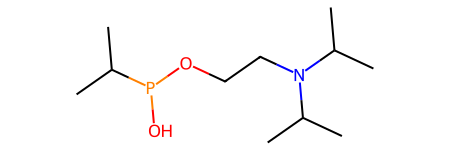

In [3]:
# 解析固定子结构分子
fixed_mol = Chem.MolFromSmiles(fixed_smiles)

# 验证固定分子是否解析成功
if fixed_mol is None:
    raise ValueError(f"固定 SMILES 无法解析: {fixed_smiles}")

print(f"固定子结构 SMILES: {fixed_smiles}")
print(f"原子数: {fixed_mol.GetNumAtoms()}")
print(f"\n所有原子信息:")
for atom in fixed_mol.GetAtoms():
    print(f"  索引 {atom.GetIdx()}: {atom.GetSymbol()} (价态: {atom.GetTotalValence()})")

print(f"\n指定的连接原子索引: {fixed_connection_atoms}")
for idx in fixed_connection_atoms:
    if idx < fixed_mol.GetNumAtoms():
        atom = fixed_mol.GetAtomWithIdx(idx)
        print(f"  索引 {idx}: {atom.GetSymbol()}")
    else:
        print(f"  警告: 索引 {idx} 超出范围!")

print("\n固定子结构分子图:")
display(fixed_mol)

# 缓存固定分子的原子数
fixed_num_atoms = fixed_mol.GetNumAtoms()

## 辅助函数定义

In [4]:
def get_connectable_atoms(mol):
    """
    确定分子中允许形成新键的原子索引列表。
    只要原子有隐式氢原子（可以被替换），就认为可连接。
    
    参数:
        mol: RDKit Mol 对象
    
    返回:
        list: 可连接的原子索引列表
    """
    connectable = []
    
    for atom in mol.GetAtoms():
        # 获取该原子的总氢原子数（包括隐式氢）
        num_implicit_h = atom.GetTotalNumHs()
        
        # 如果有隐式氢，说明可以替换成其他基团
        if num_implicit_h > 0:
            connectable.append(atom.GetIdx())
    
    return connectable


def combine_molecules(skeleton_mol, fixed_mol, skel_atom_idx, fixed_atom_idx, fixed_num_atoms):
    """
    将骨架分子和固定分子通过指定的原子连接。
    
    参数:
        skeleton_mol: 骨架分子（RDKit Mol）
        fixed_mol: 固定子结构分子（RDKit Mol）
        skel_atom_idx: 骨架中的连接原子索引
        fixed_atom_idx: 固定分子中的连接原子索引
        fixed_num_atoms: 固定分子的原子数量（缓存值）
    
    返回:
        RDKit Mol 对象，表示合并后的分子
    """
    # 合并两个分子（简单拼接，不形成键）
    combo = Chem.RWMol(Chem.CombineMols(fixed_mol, skeleton_mol))
    
    # 计算骨架分子在合并后的原子索引偏移
    # 固定分子的原子索引保持不变（0 到 fixed_num_atoms-1）
    # 骨架分子的原子索引需要加上偏移量
    new_skel_idx = skel_atom_idx + fixed_num_atoms
    
    # 在两个分子之间添加连接键（默认单键）
    combo.AddBond(fixed_atom_idx, new_skel_idx, Chem.BondType.SINGLE)
    
    return combo


def process_single_smiles(smiles, fixed_mol, fixed_num_atoms, fixed_connection_atoms):
    """
    处理单个 SMILES，将其与固定子结构连接。
    
    参数:
        smiles: 输入的 SMILES 字符串
        fixed_mol: 固定子结构分子
        fixed_num_atoms: 固定分子的原子数量
        fixed_connection_atoms: 固定分子的连接点索引列表
    
    返回:
        set: 该 SMILES 生成的所有唯一组合 SMILES 集合
    """
    local_smiles = set()
    
    # 解析输入的 SMILES
    try:
        skeleton_mol = Chem.MolFromSmiles(smiles)
        if skeleton_mol is None:
            return local_smiles
    except Exception:
        return local_smiles
    
    # 获取骨架中可连接的原子
    skel_connectable = get_connectable_atoms(skeleton_mol)
    
    # 如果骨架没有可连接的原子，直接返回
    if not skel_connectable:
        return local_smiles
    
    # 枚举骨架和固定子结构的连接组合
    for skel_idx in skel_connectable:
        for fixed_idx in fixed_connection_atoms:
            try:
                # 合并分子
                combined_mol = combine_molecules(
                    skeleton_mol, fixed_mol, skel_idx, fixed_idx, fixed_num_atoms
                )
                
                # 检查合并后分子的化学可行性
                rdmolops.SanitizeMol(combined_mol)
                
                # 生成规范化 SMILES
                combined_smiles = Chem.MolToSmiles(combined_mol, canonical=True)
                local_smiles.add(combined_smiles)
                
            except Exception:
                # 不合法的组合直接跳过
                continue
    
    return local_smiles


print("✓ 辅助函数定义完成")

✓ 辅助函数定义完成


## 测试：读取输入文件

In [5]:
# 读取并统计输入文件
with open(input_smiles_file, "r", encoding="utf-8") as f:
    input_smiles_list = [line.strip() for line in f if line.strip()]

print("=" * 60)
print(f"输入文件: {input_smiles_file}")
print(f"总共有 {len(input_smiles_list)} 个 SMILES")
print("=" * 60)

# 显示前10个 SMILES
print("\n前10个 SMILES:")
for i, smi in enumerate(input_smiles_list[:10], 1):
    print(f"  {i}. {smi}")

if len(input_smiles_list) > 10:
    print(f"  ... 还有 {len(input_smiles_list) - 10} 个")

输入文件: D:/geng/origin_smiles/All_C_SMILES.txt
总共有 932 个 SMILES

前10个 SMILES:
  1. C
  2. CC
  3. CCC
  4. C(C)C
  5. CC(C)C
  6. CCCC
  7. CC1CC1
  8. C1CCC1
  9. CC(C)(C)C
  10. CCC(C)C
  ... 还有 922 个


## 测试：处理第一个 SMILES

测试 SMILES: C
原子数: 1
可连接的原子索引: [0]

骨架分子结构:


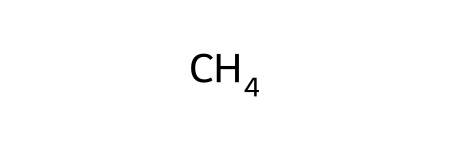


生成了 1 个组合分子

生成的组合 SMILES:
  1. COP(OCCN(C(C)C)C(C)C)C(C)C

前3个组合分子的结构:


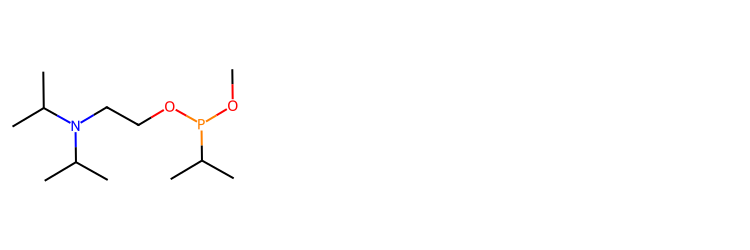

In [6]:
if input_smiles_list:
    test_smiles = input_smiles_list[0]
    print(f"测试 SMILES: {test_smiles}")
    
    # 解析并显示
    test_mol = Chem.MolFromSmiles(test_smiles)
    if test_mol:
        print(f"原子数: {test_mol.GetNumAtoms()}")
        print(f"可连接的原子索引: {get_connectable_atoms(test_mol)}")
        print("\n骨架分子结构:")
        display(test_mol)
        
        # 测试连接
        test_results = process_single_smiles(
            test_smiles, fixed_mol, fixed_num_atoms, fixed_connection_atoms
        )
        
        print(f"\n生成了 {len(test_results)} 个组合分子")
        print("\n生成的组合 SMILES:")
        for i, smi in enumerate(sorted(test_results)[:5], 1):
            print(f"  {i}. {smi}")
        
        if len(test_results) > 5:
            print(f"  ... 还有 {len(test_results) - 5} 个")
        
        # 可视化前几个结果
        if test_results:
            print("\n前3个组合分子的结构:")
            sample_mols = [Chem.MolFromSmiles(smi) for smi in sorted(test_results)[:3]]
            display(Draw.MolsToGridImage(sample_mols, molsPerRow=3, subImgSize=(250, 250)))
    else:
        print("无法解析测试 SMILES")
else:
    print("输入文件为空")

## 主流程：批量处理所有 SMILES

In [7]:
print("=" * 60)
print("开始批量处理 SMILES 文件")
print("=" * 60)
print(f"输入文件: {input_smiles_file}")
print(f"输出文件: {output_file}")
print(f"固定子结构: {fixed_smiles}")
print(f"连接点: {fixed_connection_atoms}")
print("-" * 60)

# 统计变量
total_molecules = 0          # 生成的唯一分子总数
unique_smiles = set()        # 用于去重的 SMILES 集合
processed_count = 0          # 成功处理的 SMILES 数量
failed_count = 0             # 失败的 SMILES 数量
write_buffer = []            # 批量写入缓冲区

start_time = time.time()

# 打开输出文件，开始处理
with open(output_file, "w", encoding="utf-8") as fout:
    for line_num, smiles in enumerate(input_smiles_list, 1):
        # 处理单个 SMILES
        result_smiles = process_single_smiles(
            smiles, fixed_mol, fixed_num_atoms, fixed_connection_atoms
        )
        
        if result_smiles:
            processed_count += 1
            
            # 批量去重和写入
            for new_smiles in result_smiles:
                if new_smiles not in unique_smiles:
                    unique_smiles.add(new_smiles)
                    write_buffer.append(new_smiles + "\n")
                    total_molecules += 1
                    
                    # 当缓冲区达到一定大小时，批量写入文件
                    if len(write_buffer) >= BATCH_WRITE_SIZE:
                        fout.writelines(write_buffer)
                        write_buffer.clear()
        else:
            failed_count += 1
        
        # 每处理 100 行输出一次进度信息
        if line_num % 100 == 0:
            elapsed = time.time() - start_time
            speed = line_num / elapsed if elapsed > 0 else 0
            print(f"已处理 {line_num}/{len(input_smiles_list)} 个 SMILES, "
                  f"成功 {processed_count} 个, 失败 {failed_count} 个, "
                  f"生成 {total_molecules} 个唯一分子, "
                  f"速度: {speed:.2f} SMILES/秒")
    
    # 写入剩余的缓冲区数据
    if write_buffer:
        fout.writelines(write_buffer)
        write_buffer.clear()

# ==============================================
# 输出最终统计信息
# ==============================================
elapsed_time = time.time() - start_time
print("=" * 60)
print("处理完成!")
print(f"总共读取了 {len(input_smiles_list)} 个 SMILES")
print(f"成功处理了 {processed_count} 个 SMILES")
print(f"失败了 {failed_count} 个 SMILES")
print(f"生成了 {total_molecules} 个唯一合法分子 (已去重)")
print(f"总用时: {elapsed_time:.2f} 秒")
print(f"平均速度: {len(input_smiles_list)/elapsed_time:.2f} SMILES/秒")
print(f"输出文件: {output_file}")
print("=" * 60)

开始批量处理 SMILES 文件
输入文件: D:/geng/origin_smiles/All_C_SMILES.txt
输出文件: D:/geng/1_B_10/1_B_10_i-Pr.txt
固定子结构: OP(C(C)C)(OCCN(C(C)C)(C(C)C))
连接点: [0]
------------------------------------------------------------
已处理 100/932 个 SMILES, 成功 100 个, 失败 0 个, 生成 405 个唯一分子, 速度: 1060.03 SMILES/秒
已处理 200/932 个 SMILES, 成功 200 个, 失败 0 个, 生成 961 个唯一分子, 速度: 982.09 SMILES/秒
已处理 100/932 个 SMILES, 成功 100 个, 失败 0 个, 生成 405 个唯一分子, 速度: 1060.03 SMILES/秒
已处理 200/932 个 SMILES, 成功 200 个, 失败 0 个, 生成 961 个唯一分子, 速度: 982.09 SMILES/秒
已处理 300/932 个 SMILES, 成功 300 个, 失败 0 个, 生成 1585 个唯一分子, 速度: 925.02 SMILES/秒已处理 300/932 个 SMILES, 成功 300 个, 失败 0 个, 生成 1585 个唯一分子, 速度: 925.02 SMILES/秒

已处理 400/932 个 SMILES, 成功 400 个, 失败 0 个, 生成 2256 个唯一分子, 速度: 883.07 SMILES/秒
已处理 500/932 个 SMILES, 成功 500 个, 失败 0 个, 生成 2882 个唯一分子, 速度: 863.28 SMILES/秒
已处理 400/932 个 SMILES, 成功 400 个, 失败 0 个, 生成 2256 个唯一分子, 速度: 883.07 SMILES/秒
已处理 500/932 个 SMILES, 成功 500 个, 失败 0 个, 生成 2882 个唯一分子, 速度: 863.28 SMILES/秒
已处理 600/932 个 SMILES, 成功 600 个, 失败 0 个, 生成 359

## 验证输出文件

=== 输出文件验证 ===
文件: D:/geng/1_B_10/1_B_10_i-Pr.txt
总分子数: 6148

前10个组合 SMILES:
  1. COP(OCCN(C(C)C)C(C)C)C(C)C (16 个原子)
  2. CCOP(OCCN(C(C)C)C(C)C)C(C)C (17 个原子)
  3. CCCOP(OCCN(C(C)C)C(C)C)C(C)C (18 个原子)
  4. CC(C)OP(OCCN(C(C)C)C(C)C)C(C)C (18 个原子)
  5. CC(C)COP(OCCN(C(C)C)C(C)C)C(C)C (19 个原子)
  6. CC(C)N(CCOP(OC(C)(C)C)C(C)C)C(C)C (19 个原子)
  7. CCCCOP(OCCN(C(C)C)C(C)C)C(C)C (19 个原子)
  8. CCC(C)OP(OCCN(C(C)C)C(C)C)C(C)C (19 个原子)
  9. CC(C)N(CCOP(OCC1CC1)C(C)C)C(C)C (19 个原子)
  10. CC(C)N(CCOP(OC1(C)CC1)C(C)C)C(C)C (19 个原子)
  ... 还有 6138 个

随机展示 12 个组合分子结构:


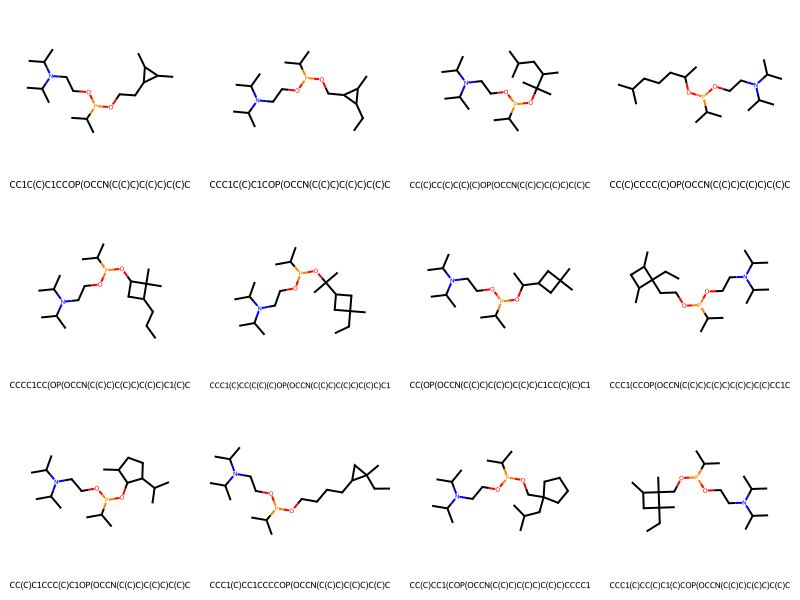


✓ 验证完成！成功生成 6148 个组合分子


In [8]:
# 读取生成的 SMILES 文件并验证
with open(output_file, "r", encoding="utf-8") as f:
    output_smiles_list = [line.strip() for line in f if line.strip()]

print(f"=== 输出文件验证 ===")
print(f"文件: {output_file}")
print(f"总分子数: {len(output_smiles_list)}")
print("\n前10个组合 SMILES:")
for i, smi in enumerate(output_smiles_list[:10], 1):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        num_atoms = mol.GetNumAtoms()
        print(f"  {i}. {smi} ({num_atoms} 个原子)")
    else:
        print(f"  {i}. {smi} (解析失败!)")

if len(output_smiles_list) > 10:
    print(f"  ... 还有 {len(output_smiles_list) - 10} 个")

# 随机展示一些结构
import random
print("\n随机展示 12 个组合分子结构:")
sample_size = min(12, len(output_smiles_list))
sample_smiles = random.sample(output_smiles_list, sample_size)
sample_mols = [Chem.MolFromSmiles(smi) for smi in sample_smiles]
display(Draw.MolsToGridImage(sample_mols, molsPerRow=4, subImgSize=(200, 200), legends=sample_smiles))

print(f"\n✓ 验证完成！成功生成 {len(output_smiles_list)} 个组合分子")